## Phase 2: The Aggression-Risk Trade-off - When should IPL Teams Attack?
In Phase 1, I measured how IPL batting aggression evolved over 18 seasons. In Phase 2, I build a model that predicts when aggression actually pays off and when it backfires.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
deliveries = pd.read_csv("deliveries_updated_ipl_upto_2025.csv")
matches = pd.read_csv("matches_updated_ipl_upto_2025.csv")
deliveries_m = deliveries.merge(matches[['matchId', 'season']], on = 'matchId')

print(f"Deliveries: {deliveries_m.shape}")

Deliveries: (278205, 21)


## Building the Match State
For every ball, we need to know the current situation - how many runs scored so far, wickets lost, which over, what's the target, etc. These become our model's features.

In [4]:
deliveries_m['total_runs'] = deliveries_m['batsman_runs'] + deliveries_m['extras']
innings2 = deliveries_m[deliveries_m['inning'] == 2].copy()
print(f"Innings 2 deliveries: {len(innings2):,}")

Innings 2 deliveries: 133,903


## Feature Engineering
Creating match-state features for every delivery in innings 2. These describe the situation at the moment each ball is bowled.

In [5]:
# sort by match and ball order
innings2 = innings2.sort_values(['matchId', 'over', 'ball']).reset_index(drop = True)

# Cumulative runs scored so far in this innings
innings2['cum_runs'] = innings2.groupby('matchId')['total_runs'].cumsum()

# Cumulative wickets fallen (1 if someone got out, 0 if not)
innings2['is_wicket'] = innings2['dismissal_kind'].notna().astype(int)
innings2['cum_wickets'] = innings2.groupby('matchId')['is_wicket'].cumsum()

# Over number
innings2['over_num'] = innings2['over'] + 1

# Balls bowled so far in this innings 
innings2['balls_bowled'] = innings2.groupby('matchId').cumcount() + 1

print(innings2[['matchId', 'over_num', 'ball', 'total_runs', 'cum_runs', 'cum_wickets', 'balls_bowled']].head(20))

    matchId  over_num  ball  total_runs  cum_runs  cum_wickets  balls_bowled
0    335982         1     1           1         1            0             1
1    335982         1     2           1         2            0             2
2    335982         1     3           0         2            0             3
3    335982         1     4           1         3            0             4
4    335982         1     5           1         4            0             5
5    335982         1     6           0         4            0             6
6    335982         1     7           0         4            0             7
7    335982         2     1           0         4            1             8
8    335982         2     2           0         4            1             9
9    335982         2     3           4         8            1            10
10   335982         2     4           1         9            1            11
11   335982         2     5           0         9            1            12

In [6]:
# First, calculate what innings 1 scored (the target)
innings1 = deliveries_m[deliveries_m['inning'] == 1].copy()
targets = innings1.groupby('matchId')['total_runs'].sum().reset_index()
targets.columns = ['matchId', 'target']
targets['target'] = targets['target'] + 1  # need one more run to win

# Merge target into innings 2
innings2 = innings2.merge(targets, on='matchId', how='left')

# Calculate runs still needed
innings2['runs_needed'] = innings2['target'] - innings2['cum_runs']

# Calculate required run rate
innings2['balls_remaining'] = 120 - innings2['balls_bowled']
innings2['required_rr'] = (innings2['runs_needed'] / (innings2['balls_remaining'] / 6))

# Current run rate
innings2['current_rr'] = innings2['cum_runs'] / (innings2['balls_bowled'] / 6)

# Wickets in hand
innings2['wickets_in_hand'] = 10 - innings2['cum_wickets']

print(innings2[['matchId', 'over_num', 'cum_runs', 'target', 'runs_needed', 
                'required_rr', 'current_rr', 'wickets_in_hand']].head(20))

    matchId  over_num  cum_runs  target  runs_needed  required_rr  current_rr  \
0    335982         1         1     223          222    11.193277    6.000000   
1    335982         1         2     223          221    11.237288    6.000000   
2    335982         1         2     223          221    11.333333    4.000000   
3    335982         1         3     223          220    11.379310    4.500000   
4    335982         1         4     223          219    11.426087    4.800000   
5    335982         1         4     223          219    11.526316    4.000000   
6    335982         1         4     223          219    11.628319    3.428571   
7    335982         2         4     223          219    11.732143    3.000000   
8    335982         2         4     223          219    11.837838    2.666667   
9    335982         2         8     223          215    11.727273    4.800000   
10   335982         2         9     223          214    11.779817    4.909091   
11   335982         2       

## Data Cleaning and Sanity Checks
Following proper protocols: checking for nulls, missing values, duplicates, and feature quality before modelling. 

## Sanity Checks

In [7]:
# Check for nulls in our key features
print("=== Null values in Key columns ===")
key_cols = ['over_num', 'cum_runs', 'target', 'runs_needed', 'required_rr', 'current_rr', 'wickets_in_hand', 'balls_remaining', 'batsman_runs']
print(innings2[key_cols].isnull().sum())

print("\n=== Basic stats ===")
print(innings2[key_cols].describe().round(2))

print("\n === Any infinite values? ===")
print((innings2[key_cols] == np.inf).sum())
print(f"\n === Total matches in innings 2: {innings2['matchId'].nunique()} ===")
print(f"=== Total deliveries: {len(innings2):,} ===")
      

=== Null values in Key columns ===
over_num           0
cum_runs           0
target             0
runs_needed        0
required_rr        8
current_rr         0
wickets_in_hand    0
balls_remaining    0
batsman_runs       0
dtype: int64

=== Basic stats ===
        over_num   cum_runs     target  runs_needed  required_rr  current_rr  \
count  133903.00  133903.00  133903.00    133903.00    133895.00   133903.00   
mean        9.93      75.26     170.26        95.00          NaN        7.43   
std         5.56      48.19      31.58        51.38          NaN        2.31   
min         1.00       0.00      63.00       -15.00         -inf        0.00   
25%         5.00      35.00     150.00        55.00         7.47        6.22   
50%        10.00      72.00     169.00        94.00         9.32        7.44   
75%        15.00     111.00     190.00       133.00        11.80        8.68   
max        20.00     262.00     288.00       287.00          inf       36.00   

       wickets_in_han

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


## Problem 1: 
required_rr has 8 nulls and 635 infinite values. Infinite values happen when balls_remaining is 0 (we cannot divide by zero). Nulls happen when target is missing. We need to remove those rows

## Problem 2:
runs_needed has negative values (min is -15). This means the team already passes the target, the chase is over but there are extra balls recorded. We should filter these out.

## Problem 3:
balls remaining has negative values (min is -16). Same issue, deliveries recorded after the match should have ended.

## Cleaning the Data
Removing rows with infinite values, negative balls remaining, and completed chases where the team already passed the target.

In [8]:
print(f"Before cleaning: {len(innings2):,} rows")

# Remove rows where required_rr is infinite or null

innings2 = innings2[~innings2['required_rr'].isin([np.inf, -np.inf])]
innings2 = innings2.dropna(subset=['required_rr'])

# Remove rows where chase is already over (runs_needed <= 0)
innings2 = innings2[innings2['runs_needed'] > 0]

# Remove rows where balls_remaining <= 0
innings2 = innings2[innings2['balls_remaining'] > 0]

print(f"After cleaning: {len(innings2):,} rows")
print(f"Matches remaining: {innings2['matchId'].nunique()}")

# Verify
print(f"\nInfinite values in required_rr: {(innings2['required_rr'] == np.inf).sum()}")
print(f"Null values in required_rr: {innings2['required_rr'].isnull().sum()}")
print(f"Min runs_needed: {innings2['runs_needed'].min()}")
print(f"Min balls_remaining: {innings2['balls_remaining'].min()}")


Before cleaning: 133,903 rows
After cleaning: 130,283 rows
Matches remaining: 1164

Infinite values in required_rr: 0
Null values in required_rr: 0
Min runs_needed: 1
Min balls_remaining: 1


### We went from 133,903 to 130, 282 rows and removed about 3600 rows that were problematic

## Creating the Target Variable
For each delivery, we need to know: did the chasing team eventually win this match? This is what the model learns to predict - the win probability at each ball.

In [9]:
# Did the chasing team win this match?
# The chasing team is the batting team in innings 2
# We check if the batting team matches the match winner

chase_winners = innings2.groupby('matchId').agg(
    chasing_team=('batting_team', 'first')
).reset_index()

chase_winners = chase_winners.merge(matches[['matchId', 'winner']], on='matchId')
chase_winners['chase_won'] = (chase_winners['chasing_team'] == chase_winners['winner']).astype(int)

# Merge back into innings2
innings2 = innings2.merge(chase_winners[['matchId', 'chase_won']], on='matchId', how='left')

print(f"Chase won distribution:")
print(innings2.groupby('chase_won')['matchId'].nunique())
print(f"\nTotal matches: {innings2['matchId'].nunique()}")

Chase won distribution:
chase_won
0    543
1    621
Name: matchId, dtype: int64

Total matches: 1164


## Adding Phase and Aggression Features
Creating the innings phase (Powerplay/Middle/Death) and marking whether each delivery was an aggressive shot (boundary) or not.

In [10]:
def get_phase(over_num):
    if over_num <= 6:
        return 'Powerplay'
    elif over_num <= 15:
        return 'Middle'
    else:
        return 'Death'
innings2['phase'] = innings2['over_num'].apply(get_phase)

# Was this ball aggressive ? (boundary = 4, 6)

innings2['is_boundary'] = innings2['batsman_runs'].isin([4, 6]).astype(int)

# Is it a dot ball?
innings2['is_dot'] = (innings2['batsman_runs'] == 0).astype(int)

# Pressure: how far behind is the required rate vs current rate?
innings2['rr_gap'] = innings2['required_rr'] - innings2['current_rr']

print("Phase distribution: ")
print(innings2['phase'].value_counts())
print(f"\nBoundary %: {innings2['is_boundary'].mean()*100:.1f}%")
print(f"Dot ball %: {innings2['is_dot'].mean()*100:.1f}%")
print(f"\nAvg RR gap: {innings2['rr_gap'].mean():.2f}")

Phase distribution: 
phase
Middle       62811
Powerplay    43469
Death        24003
Name: count, dtype: int64

Boundary %: 16.4%
Dot ball %: 40.3%

Avg RR gap: 4.55


## Feature Correlation Check
Checking for overlapping or highly correlated features before training the model. Highly correlated features can confuse the model.

                 over_num  cum_runs  runs_needed  required_rr  current_rr  \
over_num             1.00      0.93        -0.82         0.29        0.14   
cum_runs             0.93      1.00        -0.79         0.26        0.38   
runs_needed         -0.82     -0.79         1.00        -0.08       -0.17   
required_rr          0.29      0.26        -0.08         1.00       -0.01   
current_rr           0.14      0.38        -0.17        -0.01        1.00   
wickets_in_hand     -0.74     -0.61         0.46        -0.40        0.06   
balls_remaining     -1.00     -0.93         0.82        -0.30       -0.15   
rr_gap               0.27      0.20        -0.06         0.99       -0.14   

                 wickets_in_hand  balls_remaining  rr_gap  
over_num                   -0.74            -1.00    0.27  
cum_runs                   -0.61            -0.93    0.20  
runs_needed                 0.46             0.82   -0.06  
required_rr                -0.40            -0.30    0.99  
curren

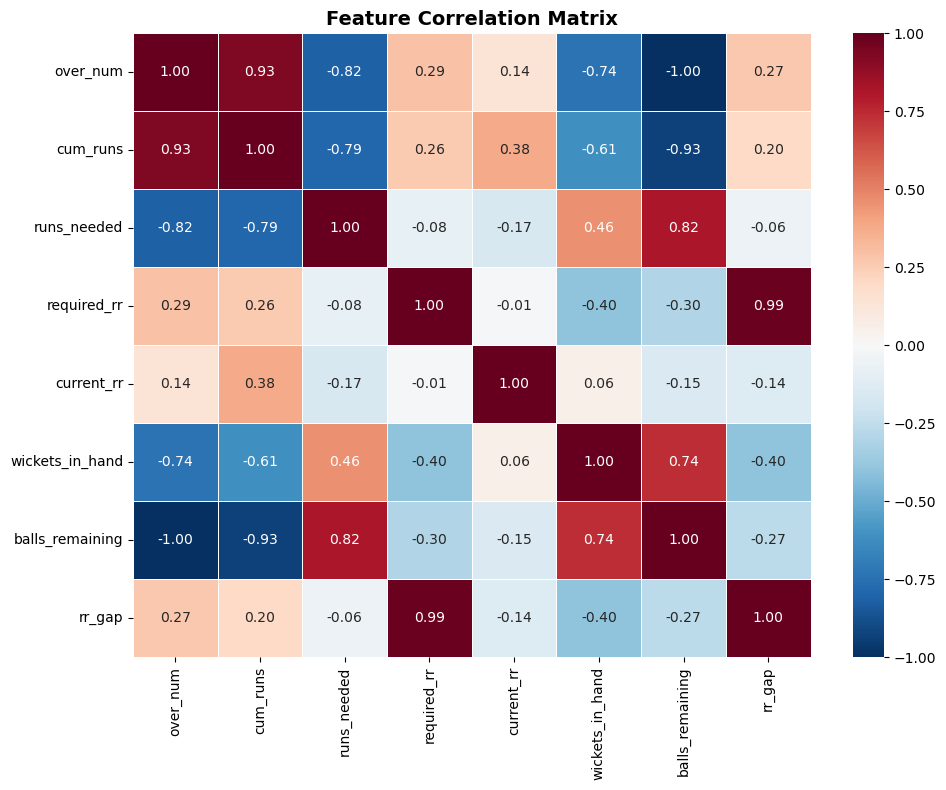

In [11]:
feature_cols = ['over_num', 'cum_runs', 'runs_needed', 'required_rr', 'current_rr', 'wickets_in_hand', 'balls_remaining', 'rr_gap']

corr = innings2[feature_cols].corr().round(2)

print(corr)

# Let's Visualize
fig, ax = plt.subplots(figsize = (10, 8))
sns.heatmap(corr, annot = True, cmap='RdBu_r', center = 0, ax = ax, linewidth = 0.5, fmt = '.2f')
ax.set_title('Feature Correlation Matrix', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('phase2_01_correlation_matrix.png')
plt.show()

## Removing Overlapping features

1. over_num and balls_remaining: correlation = -1.00. These are perfectly correlated - balls_remaining = 120 - balls_bowled, and balls_bowled increases with over_num. They contain the exact same information. We need to drop one. Let's keep balls_remaining because it's more meaningful for chasing (how many balls do I have left?)

2. required_rr and rr_gap: correlation = 0.99 Almost identical. rr_gap = required_rr - current_rr. Since current_rr is also separate feature, keeping both required_rr and rr_gap is redundant. Let's drop required_rr and keep rr_gap because it captures the pressure relative to current scoring which is more useful.

3. cum_runs and balls_remaining: correlation = -0.93 High but not perfect. This makes more sense as more balls are bowled, more runs are scored. But they're not identical (some overs have more runs than others). We'll keep both for now.

In [12]:
# Final feature set
features = ['cum_runs', 'runs_needed', 'current_rr', 'wickets_in_hand', 'balls_remaining', 'rr_gap', 'is_boundary', 'is_dot']
target = 'chase_won'

# Check final features
print("Final features:")
for f in features:
    print(f" {f}: nulls={innings2[f].isnull().sum()}, min={innings2[f].min():.2f}, max={innings2[f].max():.2f}")

print(f"\nTarget: {target}")
print(innings2[target].value_counts(normalize=True).round(3))




Final features:
 cum_runs: nulls=0, min=0.00, max=261.00
 runs_needed: nulls=0, min=1.00, max=287.00
 current_rr: nulls=0, min=0.00, max=36.00
 wickets_in_hand: nulls=0, min=0.00, max=10.00
 balls_remaining: nulls=0, min=1.00, max=119.00
 rr_gap: nulls=0, min=-29.09, max=864.76
 is_boundary: nulls=0, min=0.00, max=1.00
 is_dot: nulls=0, min=0.00, max=1.00

Target: chase_won
chase_won
1    0.517
0    0.483
Name: proportion, dtype: float64


## Outlier
This is now the clean data, no nulls, balanced target (51.7% wins vs 48.3% losses). Notice, rr_gap has a max of 864.76. That's an extreme outlier, it means required run rate was absurdly high in some situation.

In [13]:
# Cap extreme rr_gap values
print(f"rr_gap before capping:")
print(f" 99th percentile: {innings2['rr_gap'].quantile(0.99):.2f}")
print(f" Max: {innings2['rr_gap'].max():.2f}")
innings2['rr_gap'] = innings2['rr_gap'].clip(-30, 30)
print(f"\nrr_gap after capping:")
print(f"  Min: {innings2['rr_gap'].min():.2f}")
print(f"  Max: {innings2['rr_gap'].max():.2f}")

rr_gap before capping:
 99th percentile: 58.48
 Max: 864.76

rr_gap after capping:
  Min: -29.09
  Max: 30.00


# Train/Test split and Modelling:

In [14]:
# Splitting the data by season, training on old data and testing on recent one
train = innings2[~innings2['season'].isin(['2023', '2024', '2025'])]
test = innings2[innings2['season'].isin(['2023', '2024', '2025'])]

print(f"Training set: {len(train):,} deliveries from {train['matchId'].nunique()} matches")
print(f"Test set: {len(test):,} deliveries from {test['matchId'].nunique()} matches")

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# Random Forest
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability of chase being won

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Training set: 106,079 deliveries from 948 matches
Test set: 24,204 deliveries from 216 matches

Accuracy: 0.761

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.78     12732
           1       0.78      0.69      0.73     11472

    accuracy                           0.76     24204
   macro avg       0.76      0.76      0.76     24204
weighted avg       0.76      0.76      0.76     24204



## Feature Importance - What actually drives a successful Chase?
Which features does them model rely on most to predict whether a chase succeeds?

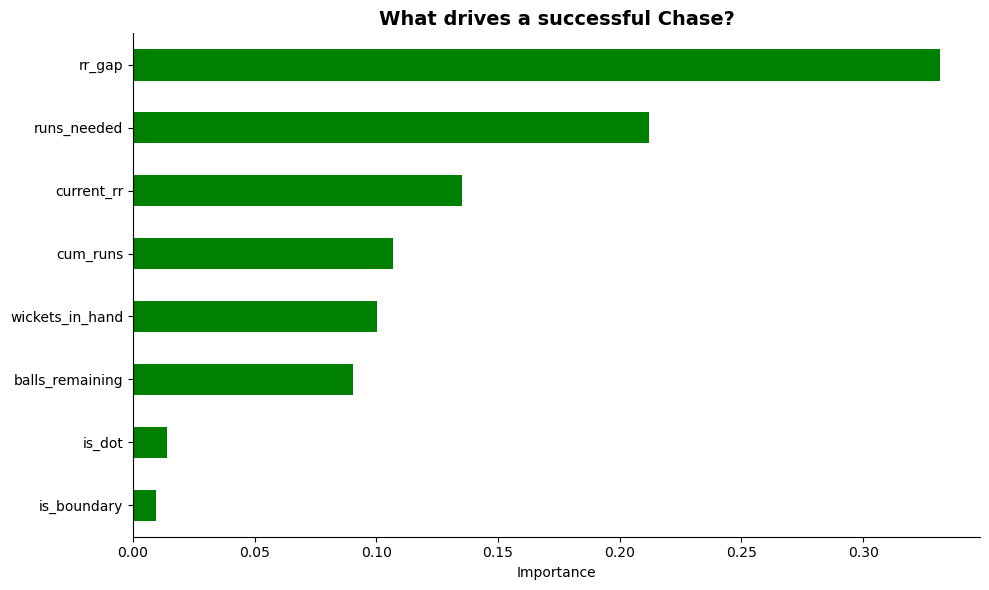

In [16]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index = features).sort_values(ascending = True)

fig, ax = plt.subplots(figsize = (10, 6))
feat_imp.plot(kind = 'barh', color = 'green', ax = ax)
ax.set_xlabel("Importance")
ax.set_title("What drives a successful Chase?", fontsize = 14, fontweight = 'bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('phase2_02_feature_importance.png', dpi = 150)
plt.show()

# The Goldmine Finding
1. rr_gap is by far the most important feature (0.33). The gap between required run rate and current run rate, the pressure metrics drives the prediction more than anything else. This connects beautifully to Phase 1 analysis

2. runs_needed is second (0.21). How many runs are left to chase matters alot

3. current_rr is third (0.13). How fast the team is currently scoring

4. is_dot and is_boundary (near 0.01). This is the most interesting finding: whether any single ball is a boundary or dot barely matters. What matters is the cumulative situation, the pressure, the runs needed, the wickets in hand. Individual balls don't decide matches. Match state does.

### " A single six doesn't win you a match. Being in the right position - low pressure  runs on track, wickets in hand that is what derives the successful chases "

## Visulizing a Real Match - Win Probability Curve
Using the model to show how win Probabilty changes ball-by-ball during an actual IPL match. This is the model in action.

In [17]:
# Let's find a close match in the test set - one that the chasing team won narrowly
test_matches = test.groupby('matchId').agg(
    chase_won=('chase_won', 'first'),
    target = ('target', 'first'),
    final_runs = ('cum_runs', 'last'),
    final_wickets = ('cum_wickets', 'last')
).reset_index()

# Close matches, chasing team won with less than 10 runs to spare
close_wins = test_matches[(test_matches['chase_won'] == 1) &
((test_matches['target'] - test_matches['final_runs']) < 10)]

print("Close wins in test set:")
print(close_wins.head(10))

Close wins in test set:
    matchId  chase_won  target  final_runs  final_wickets
0   1359475          1     179         171              5
4   1359479          1     172         166              2
6   1359481          1     163         161              4
9   1359484          1     122         121              5
11  1359486          1     158         155              3
13  1359488          1     144         141              2
15  1359490          1     173         169              4
17  1359492          1     154         150              4
20  1359495          1     160         153              8
21  1359496          1     186         185              5


Match Id 1359495 is the most dramatic one as the chasing team won with 8 wickets lost chasing 160. That means they were losing wickets constantly but still scraped through

# Win Probability Curve - The Model in Action

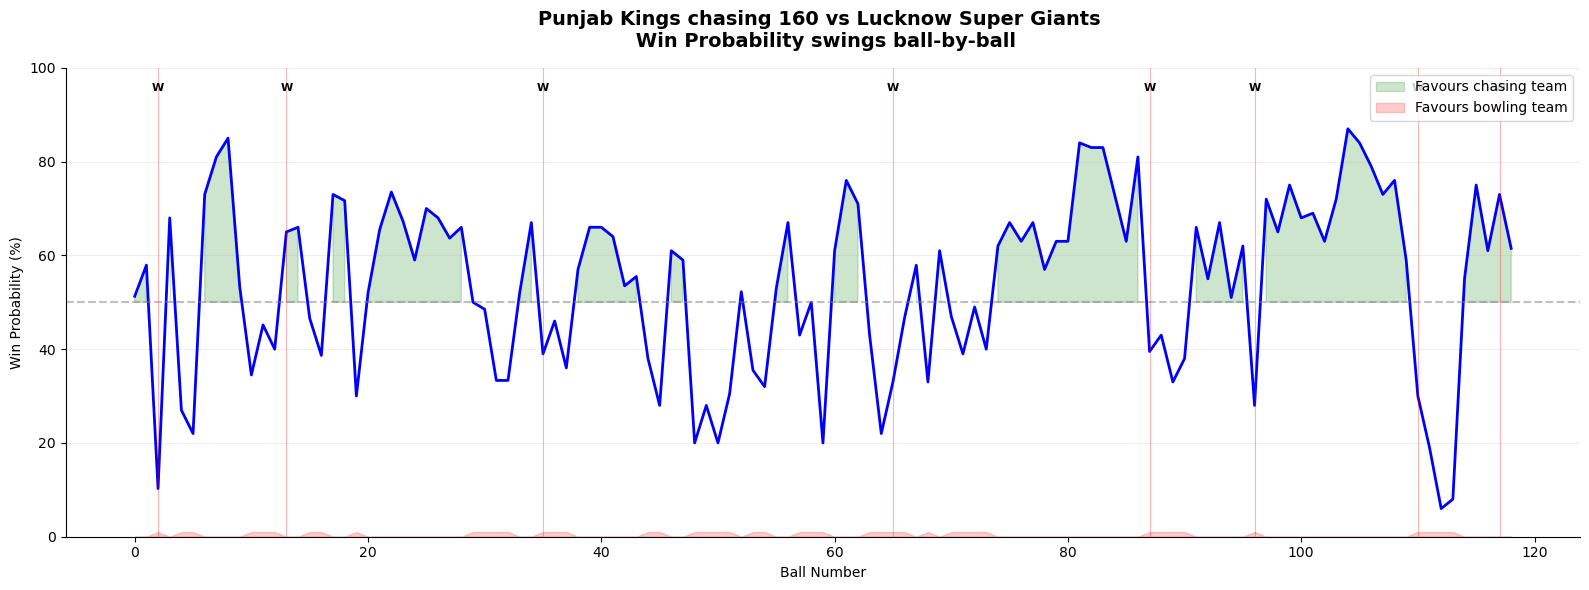

In [18]:
# Get the match data
match_id = 1359495
match_data = test[test['matchId'] == match_id].copy()

# Win Probability for each ball
match_probs = model.predict_proba(match_data[features])[:,1]
match_data['win_prob'] = match_probs

# Get match info for title
target = match_data['target'].iloc[0]
chasing_team = match_data['batting_team'].iloc[0]
bowling_team = match_data['bowling_team'].iloc[0]

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(range(len(match_data)), match_data['win_prob'] * 100,
        color = 'blue', linewidth = 2)
ax.fill_between(range(len(match_data)), match_data['win_prob'] * 100, 50, 
                where = match_data['win_prob'] > 0.5, alpha = 0.2, color = 'green', label = 'Favours chasing team')
ax.fill_between(range(len(match_data)), match_data['win_prob'] <= 0.5, alpha = 0.2, color = 'red', label = 'Favours bowling team')

# Marking Wickets
wicket_balls = match_data[match_data['is_wicket'] == 1].index
for idx, w in enumerate(wicket_balls):
    pos = match_data.index.get_loc(w)
    ax.axvline(x=pos, color='red', alpha = 0.3, linewidth = 0.8)
    ax.text(pos, 95, "W", fontsize = 8, ha = 'center', color = 'black', fontweight = 'bold')

# Reference line at 50%
ax.axhline(y = 50, color='gray', linestyle = '--', alpha = 0.5)

ax.set_xlabel("Ball Number")
ax.set_ylabel("Win Probability (%)")
ax.set_title(f"{chasing_team} chasing {target} vs {bowling_team} \n Win Probability swings ball-by-ball",
            fontsize = 14, fontweight = 'bold', pad = 15)

ax.set_ylim(0, 100)
ax.legend(loc = 'upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis = 'y', alpha = 0.2)

plt.tight_layout()
plt.savefig('phase2_03_win_probability_curve.png', dpi = 150)
plt.show()

## Explanation
This chart represents the dramatic swings. Punjab Kings win probability goes from 10% to 85% and back multiple times. Every wicket (W) causes a drop. The team was never truly safe, it kept swinging between favourable and unfavourable. And right near the end (ball ~115), it drops to almost 0% before somehow recovering. That is thrilling. 


In simpler words, 
Lucknow Super Giants batted first (innings 1) and scored 159
Punjab Kings bats second (innings 2) and need 160 to win
Our model watched Punjab King's chase by by ball

This is Punjab King's chance of winning at each ball:
80% = 0.8 Punjab Kings are very likely to win
50% = 0.5 could go either way
20% = 0.2 Punjab Kings are Probably going to lose

The green shading is the win Probability above 50%, meaning Punjab Kings are favoured.

The red shading is the win probability below 50%, meaning Lucknow Super Giants are favoured.

The red "W" lines represents when a Punjab Kings batsman got out. Notice every time a W appears, the blue line drops, losing a wicket reduces your chance of winning.

The story of the match: The line swings widly between 10% and 85%. Punjab kings kept losing wickets (8 total!) but somehow kept socring enough to stay in the game. Near ball 115, it drops to almost 0%, they were nearly dead. Then it recovered and they won.

This chart on the whole shows that the model isn't just saying "Punjab Kings will win" at the start/ It's updating its prediction at every single ball based on the changing situation. That's 120+ predictions for one match, each one reflecting the current pressure, wickets, runs needed.

If a coach is watching this in real-time would know: "We are at 30% right now, we need to attack." OR "We are at 75%, no need to take risks."

## Improving the Model - Adding more Features
Adding phase of innings and a momentum feature (run scored in the last 6 balls) to capture short-term batting rhythm.

In [19]:
# Phase as numeric (model needs numbers, not text)
phase_map = {'Powerplay':1, 'Middle': 2, 'Death': 3}
innings2['phase_num'] = innings2['phase'].map(phase_map)

#Momentum - runs scored in the last 6 balls
innings2['momentum'] = innings2.groupby('matchId')['total_runs'].transform(lambda x: x.rolling(window = 6, min_periods=1).sum()
)
print("New features")
print(innings2[['phase', 'phase_num', 'momentum']].describe())

New features
           phase_num       momentum
count  130283.000000  130283.000000
mean        1.850587       7.706539
std         0.703966       4.410748
min         1.000000       0.000000
25%         1.000000       4.000000
50%         2.000000       7.000000
75%         2.000000      10.000000
max         3.000000      33.000000


In [20]:
# Updated feature set
features_v2 = ['cum_runs', 'runs_needed', 'current_rr', 'wickets_in_hand', 
               'balls_remaining', 'rr_gap', 'is_boundary', 'is_dot',
               'phase_num', 'momentum']
target = 'chase_won'

# Re-split
train = innings2[~innings2['season'].isin(['2023', '2024', '2025'])]
test = innings2[innings2['season'].isin(['2023', '2024', '2025'])]

X_train = train[features_v2]
y_train = train[target]
X_test = test[features_v2]
y_test = test[target]

# Train
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train, y_train)

y_pred_v2 = model_v2.predict(X_test)

print(f"V1 Accuracy (8 features): 0.761")
print(f"V2 Accuracy (10 features): {accuracy_score(y_test, y_pred_v2):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_v2))

V1 Accuracy (8 features): 0.761
V2 Accuracy (10 features): 0.766

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79     12732
           1       0.79      0.69      0.74     11472

    accuracy                           0.77     24204
   macro avg       0.77      0.76      0.76     24204
weighted avg       0.77      0.77      0.76     24204



## Phase
Phase here 
1. Powerplay (overs 1-6) = 1
2. Middle (overs 7-15) = 2
3. Death (overs 16-20) = 3

We basically converted this in to numbers so that our model can use it. This is very helpful because the same situation means different things in different phases. Needing 60 runs with 6 wickets in hand is comfortable in the powerplay but is desperate in the death overs. The model needs to know which phase it is to judge the situation properly.

## Momentum

Momentum measures how many runs were scored in the last 6 balls. So when momentum is 25, the batsman just scored 25 runs in the last six 6 balls. The batting team is on fire. When momentum is 2, barely scored and the bowling team is dominating.

This captures something the other features don't. It is the **Recent Rhythm** of the match. A team that just hit three sixes feels different from a team that just played five dot balls, even if their overall run rate is the same.

## Hyperparameter Tuning
We will now use GridSearchCV to find the optimal Random Forest parameters. This tests multiple combinations and picks the best one using cross-validation.

In [21]:
from sklearn.model_selection import GridSearchCV

# Define parameters to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Running hyperparameter tuning!!!")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

# Test with best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"\nV1 Accuracy (baseline): 0.761")
print(f"V2 Accuracy (+ features): 0.766")
print(f"V3 Accuracy (+ tuning): {accuracy_score(y_test, y_pred_best):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Running hyperparameter tuning!!!
Fitting 3 folds for each of 108 candidates, totalling 324 fits


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV accuracy: 0.766

V1 Accuracy (baseline): 0.761
V2 Accuracy (+ features): 0.766
V3 Accuracy (+ tuning): 0.785

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81     12732
           1       0.81      0.71      0.76     11472

    accuracy                           0.78     24204
   macro avg       0.79      0.78      0.78     24204
weighted avg       0.79      0.78      0.78     24204



**n_estimators =** how many trees? A Random Forest means a "forest" of many decision trees. Each tree looks at the data slightly differently and makes its own predictions. The final answer is a vote, majority wins. More trees means more stable predictions but slower. 

**max_depth =** How deep can each tree think? A shallow tree (depth = 5) makes simple decisions: "if runs_needed > 100, probably lose." 

**A deep tree (depth = 30) makes complex decisions:** "if runs_needed > 100 AND wickets_in_hand < 4 AND rr_gap > 8 AND phase is death AND momentum < 5, then lose."

**Too deep =** the tree memorizes the training data instead of learning patterns. That's overfitting. Too shallow meaning the tree is so simple. That's underfitting.

**min_samples_split =** How much data before splitting? Higher values force the tree to only make decisions when it has enough evidence. This prevents overfitting on small patterns.

## Working of Hyperparameter tuning using the GridSearchCV
We have 3 inputs in n_estimators, 4 inputs in max_depth, 3 inputs in min_samples_split and 3 inputs in min_samples_leaf which means we have 3 \times 4 \times 3 \times \3 times = 108 combinations. For each combination, it does a 3-fold cross-validation (trains 3 times on different splits). So 108 \times 3 = 324 total model trainings.

The winner here is max_depth = 10, min_samples_leaf = 2, min_samples_split = 5, n_estimators = 300. This means a moderate-depth tree with enough data per leaf works fine not too complex and not too simple, something in the middle.

This leads to the accuracy jump from 76.1% to 78.5%. The same data, the same features, just better settings we will use.

## When does Aggression really Pay off?
This is where Phase 1 analysis meets Phase 2. We know aggression increased over 18 seasons. Now we ask: in which match states does being aggressive improve the chances of winning?

In [22]:
# For each ball in the test set, let's get the model's win probability
test = innings2[innings2['season'].isin(['2023', '2024', '2025'])].copy()
test['win_prob'] = best_model.predict_proba(test[features_v2])[:, 1]

# Compare: When batters hit a boundary vs when they didn't
# Group by phase and pressure level

test['pressure'] = pd.cut(test['rr_gap'],
                          bins=[-30, -2, 2, 6, 30],
                          labels = ['Ahead', 'On Track', 'Behind', 'Far Behind'])

aggression_analysis = test.groupby(['phase', 'pressure']).agg(
    avg_win_prob_boundary = ('win_prob', lambda x: x[test.loc[x.index, 'is_boundary'] ==1].mean()),
    avg_win_prob_no_boundary = ('win_prob', lambda x: x[test.loc[x.index, 'is_boundary'] == 0].mean()),
    boundary_pct = ('is_boundary', 'mean'),
    total_balls = ('is_boundary', 'count')
).dropna().round(3) 

print(aggression_analysis)

                      avg_win_prob_boundary  avg_win_prob_no_boundary  \
phase     pressure                                                      
Death     Ahead                       0.981                     0.983   
          On Track                    0.858                     0.855   
          Behind                      0.541                     0.534   
          Far Behind                  0.180                     0.145   
Middle    Ahead                       0.931                     0.935   
          On Track                    0.614                     0.617   
          Behind                      0.267                     0.281   
          Far Behind                  0.088                     0.088   
Powerplay Ahead                       0.703                     0.760   
          On Track                    0.470                     0.507   
          Behind                      0.239                     0.288   
          Far Behind                  0.112        

/var/folders/sd/4j70w1cd5gv7hd1mxtkhx5qh0000gn/T/ipykernel_11464/1353604778.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggression_analysis = test.groupby(['phase', 'pressure']).agg(


## When does Aggression Pay off? The Strategy Matrix
Comparing the win probability when batsmen hit boundaries vs when they don't, across different phases and pressure levels. This is the strategy recommendation engine.

/var/folders/sd/4j70w1cd5gv7hd1mxtkhx5qh0000gn/T/ipykernel_11464/3242895729.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_diff = test.groupby(['phase', 'pressure']).apply(


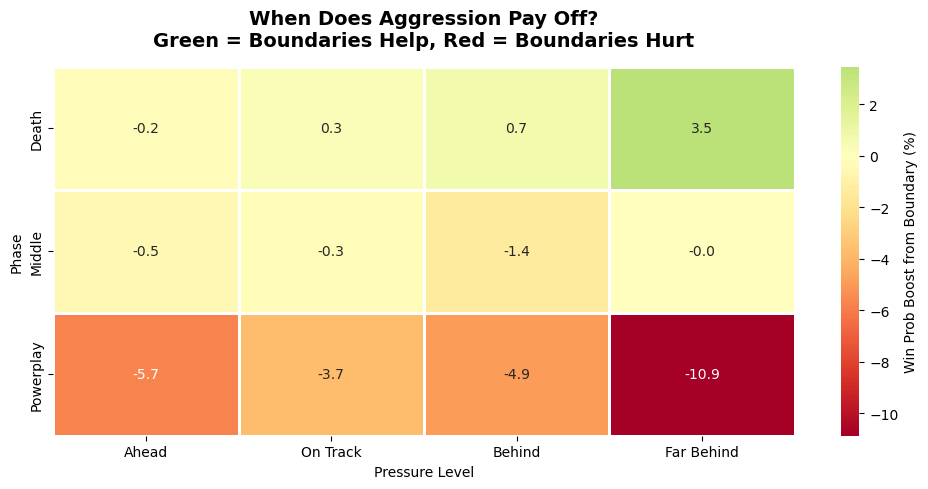

In [25]:
# Calculate the difference: boundary win prob - no boundary win prob
test['pressure'] = pd.cut(test['rr_gap'],
                          bins=[-30, -2, 2, 6, 30],
                          labels=['Ahead', 'On Track', 'Behind', 'Far Behind'])

agg_diff = test.groupby(['phase', 'pressure']).apply(
    lambda x: pd.Series({
        'boundary_wp': x[x['is_boundary'] == 1]['win_prob'].mean(),
        'no_boundary_wp': x[x['is_boundary'] == 0]['win_prob'].mean(),
    }),
    include_groups=False
).dropna()

agg_diff['aggression_benefit'] = (agg_diff['boundary_wp'] - agg_diff['no_boundary_wp']) * 100

# Reshape for heatmap
heatmap_data = agg_diff['aggression_benefit'].unstack('pressure')
heatmap_data = heatmap_data[['Ahead', 'On Track', 'Behind', 'Far Behind']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Win Prob Boost from Boundary (%)'})
ax.set_title('When Does Aggression Pay Off?\nGreen = Boundaries Help, Red = Boundaries Hurt',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Phase')
ax.set_xlabel('Pressure Level')

plt.tight_layout()
plt.savefig('phase2_04_aggression_strategy_matrix.png', dpi=150)
plt.show()

## Death overs (top rows): 
The only phase where aggression consistently helps. When far behind, hitting a boundary boosts win probability by 3.5%. The more pressure, the more boundaries help.

## Middle overs (middle rows):
Aggression is mostly neutral to slightly negative. Boundaries don't help much here, it's the phase where building steadily matters more.

## Powerplay (bottom row):
This is where Aggression hurts across every pressure level. And far behind in the powerplay, hitting boundaries is associated with a -10.9% drop in win probability.

This is the key finding because in powerplay, the chase is very early. We have 14+ overs left. Swinging hard and getting caught out early is disastrous. The team that loses wickets trying to attack in the powerplay destroys their innings. Better to survive, keep wickets, and attack later in the death overs where aggression actually pays off.

Therefore, 

Powerplay -> **DEFEND**. Preserve wickets. Don't chase the required rate yet.

Middle -> **STEADY**. Neither attack nor defend aggressively.

Death overs when behind -> **ATTACK** . This is when boundaries matter most.

## Error Analysis - Where does the Model struggle?
Let's examine where the model gets predictions wrong because a good model is not just accurate but may have its own limitations.

In [26]:
# Add predictions to test set
test['predicted'] = best_model.predict(test[features_v2])
test['correct'] = (test['predicted'] == test['chase_won']).astype(int)

# Where does the model get it wrong?
error_by_phase = test.groupby('phase').agg(
    accuracy = ('correct', 'mean'),
    total = ('correct', 'count')
).round(3)

print("Accuracy by Phase:")
print(error_by_phase)

error_by_pressure = test.groupby('pressure').agg(
    accurcy = ('correct', 'mean'),
    total = ('correct', 'count')
).round(3)
print("\nAccuracy by pressure level:")
print(error_by_pressure)

# Most interestingly accuracy by phase AND pressure
error_matrix = test.groupby(['phase', 'pressure'])['correct'].mean().unstack('pressure').round(3)
print("\nAccuracy by Phase and Pressure:")
print(error_matrix)

Accuracy by Phase:
           accuracy  total
phase                     
Death         0.871   4376
Middle        0.796  11755
Powerplay     0.721   8073

Accuracy by pressure level:
            accurcy  total
pressure                  
Ahead         0.888   3692
On Track      0.734   7852
Behind        0.717   6717
Far Behind    0.864   5943

Accuracy by Phase and Pressure:
pressure   Ahead  On Track  Behind  Far Behind
phase                                         
Death      0.993     0.862   0.735       0.878
Middle     0.906     0.743   0.731       0.922
Powerplay  0.820     0.695   0.691       0.735


/var/folders/sd/4j70w1cd5gv7hd1mxtkhx5qh0000gn/T/ipykernel_11464/1459943414.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_pressure = test.groupby('pressure').agg(
/var/folders/sd/4j70w1cd5gv7hd1mxtkhx5qh0000gn/T/ipykernel_11464/1459943414.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_matrix = test.groupby(['phase', 'pressure'])['correct'].mean().unstack('pressure').round(3)


## Our model is strong when :

1. Death overs, Ahead: 99.3% -  This is when it's basically over, the model knows it.
2. Middle overs, Far behind: 92.2% - When a chase is clearly failing, easy to predict.
3. Death overs, Far behind: 87.8% - Here, the extreme situations are predictable.

## Where our model struggles?

1. Powerplay, Behind: 69.1% - This is where the chase has barely started and too early to tell.
2. Powerplay, On Track: 69.5% - Infact here too the reasoning is same, too much of the match remaining
3. Middle overs, On Track: 74.3% - Here is when close matches in the middle are genuinely uncertain.


**True Insight:** The model is most accurate in extreme situations (clearly winning or clearly losing) and least accurate when the match is still open (powerplay, close games). Therefore, our model is 99% accurate in extreme situations and 69% in uncertain ones. 

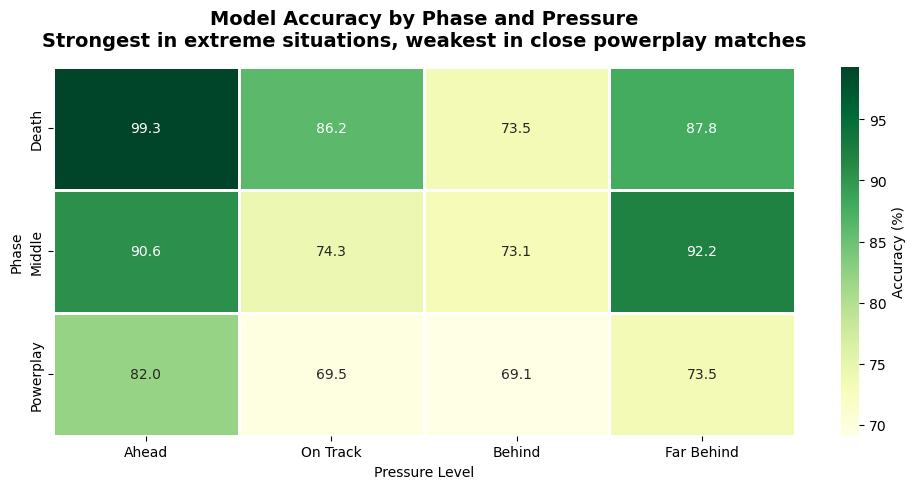

In [27]:
fig, ax = plt.subplots(figsize = (10, 5))
error_heatmap = error_matrix[['Ahead', 'On Track', 'Behind', 'Far Behind']] * 100
sns.heatmap(error_heatmap, annot = True, fmt = '.1f', cmap = 'YlGn', 
            linewidth = 1, linecolor = 'white', ax = ax, 
            cbar_kws = {'label' : 'Accuracy (%)'})
ax.set_title('Model Accuracy by Phase and Pressure\nStrongest in extreme situations, weakest in close powerplay matches',
            fontsize = 14, fontweight = 'bold', pad = 15)
ax.set_ylabel('Phase')
ax.set_xlabel('Pressure Level')

plt.tight_layout()
plt.savefig('phase2_05_error_analysis.png', dpi = 150)
plt.show()

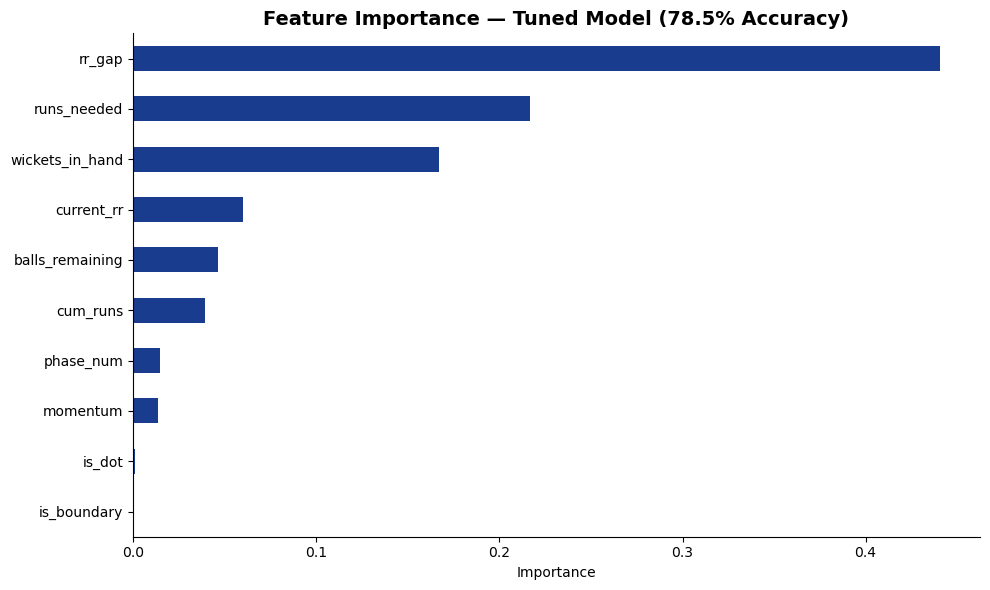

In [28]:
importances_v3 = best_model.feature_importances_
feat_imp_v3 = pd.Series(importances_v3, index=features_v2).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp_v3.plot(kind='barh', color='#1A3C8F', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — Tuned Model (78.5% Accuracy)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('phase2_06_feature_importance_tuned.png', dpi=150)
plt.show()

## Scenario after Hyperparameter tunning

**rr_gap** jumped from 0.33 to 0.44 which is even more dominant. Pressure is the number 1 predictor so far.

**wickets_in_hand** jumped from 5th to 3rd place which means tuned model values wickets more.
This connected perfectly to our aggression findings, losing wickets in the powerplay hurts because the model heavily weighs how many wickets are remaining.

**is_boundary and is_dot** are still at the bottom, confirming that single-ball outcomes don't matter. It's all about the cumulative match state.

In [29]:
## Find a close loss 
close_losses = test_matches[
    (test_matches['chase_won'] == 0) &
    (test_matches['final_wickets'] >= 7)
].copy()


print("Dramatic losses in test set :")
print(close_losses.head(10))

Dramatic losses in test set :
    matchId  chase_won  target  final_runs  final_wickets
1   1359476          0     192         146              7
2   1359477          0     194         139              7
3   1359478          0     204         108              8
8   1359483          0     205         123             10
10  1359485          0     200         138              7
19  1359494          0     175         144              9
23  1359498          0     227         207              7
24  1359499          0     193         172              8
26  1359501          0     175         150             10
32  1359507          0     236         180              7


We can see match MatchID - 1359498 is perfect as chasing run is 227 and scored 207, lost by just 20 runs with 7 wickets down. They got close by couldn't finish

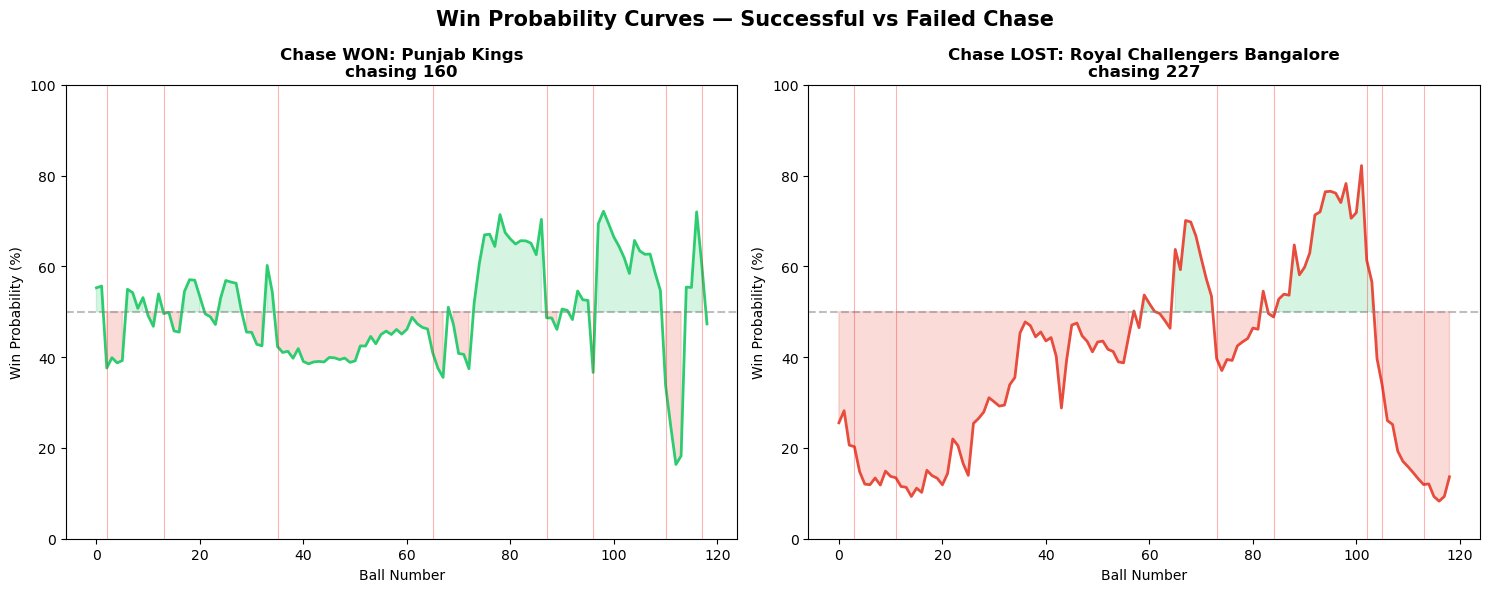

In [39]:
# Losing match win probability curve
match_id_loss = 1359498
match_data_loss = test[test['matchId'] == match_id_loss].copy()

match_probs_loss = best_model.predict_proba(match_data_loss[features_v2])[:, 1]
match_data_loss['win_prob'] = match_probs_loss

target_loss = match_data_loss['target'].iloc[0]
chasing_team_loss = match_data_loss['batting_team'].iloc[0]
bowling_team_loss = match_data_loss['bowling_team'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LEFT: The winning chase (from earlier)
match_data_win = test[test['matchId'] == 1359495].copy()
match_data_win['win_prob'] = best_model.predict_proba(match_data_win[features_v2])[:, 1]

ax = axes[0]
ax.plot(range(len(match_data_win)), match_data_win['win_prob'] * 100, color='#2ECC71', linewidth=2)
ax.fill_between(range(len(match_data_win)), match_data_win['win_prob'] * 100, 50,
                where=match_data_win['win_prob'] > 0.5, alpha=0.2, color='#2ECC71')
ax.fill_between(range(len(match_data_win)), match_data_win['win_prob'] * 100, 50,
                where=match_data_win['win_prob'] <= 0.5, alpha=0.2, color='#E74C3C')
wickets_win = match_data_win[match_data_win['is_wicket'] == 1]
for w in wickets_win.index:
    pos = match_data_win.index.get_loc(w)
    ax.axvline(x=pos, color='red', alpha=0.3, linewidth=0.8)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'Chase WON: {match_data_win["batting_team"].iloc[0]}\nchasing {match_data_win["target"].iloc[0]}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ball Number')
ax.set_ylabel('Win Probability (%)')
ax.set_ylim(0, 100)

# RIGHT: The losing chase
ax = axes[1]
ax.plot(range(len(match_data_loss)), match_data_loss['win_prob'] * 100, color='#E74C3C', linewidth=2)
ax.fill_between(range(len(match_data_loss)), match_data_loss['win_prob'] * 100, 50,
                where=match_data_loss['win_prob'] > 0.5, alpha=0.2, color='#2ECC71')
ax.fill_between(range(len(match_data_loss)), match_data_loss['win_prob'] * 100, 50,
                where=match_data_loss['win_prob'] <= 0.5, alpha=0.2, color='#E74C3C')
wickets_loss = match_data_loss[match_data_loss['is_wicket'] == 1]
for w in wickets_loss.index:
    pos = match_data_loss.index.get_loc(w)
    ax.axvline(x=pos, color='red', alpha=0.3, linewidth=0.8)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'Chase LOST: {chasing_team_loss}\nchasing {target_loss}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ball Number')
ax.set_ylabel('Win Probability (%)')
ax.set_ylim(0, 100)

fig.suptitle('Win Probability Curves — Successful vs Failed Chase',
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('phase2_07_win_prob_comparison.png', dpi=150)
plt.show()

# Comparing Models - Random Forest vs XGBoost

In [34]:
from xgboost import XGBClassifier

# XGBoost with similar hyperparameter tuning
xgb_model = XGBClassifier(
    n_estimators = 300,
    max_depth = 6, 
    learning_rate = 0.1, 
    subsample = 0.8,
    random_state = 42,
    eval_metric = 'logloss'

)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Random Forest Accuracy: 0.785")
print(f"XGBoost Accuracy: {xgb_accuracy:.3f}")
print(f"\nXGBoost Classification Report: ")
print(classification_report(y_test, y_pred_xgb))

Random Forest Accuracy: 0.785
XGBoost Accuracy: 0.776

XGBoost Classification Report: 
              precision    recall  f1-score   support

           0       0.75      0.85      0.80     12732
           1       0.81      0.69      0.75     11472

    accuracy                           0.78     24204
   macro avg       0.78      0.77      0.77     24204
weighted avg       0.78      0.78      0.77     24204



## Model evolution summary
From the above results, Random Forest Wins (78.5% vs 77.6%). Tracking the progression from baseline to final model, including the XGboost comparison with Random Forest Classifier

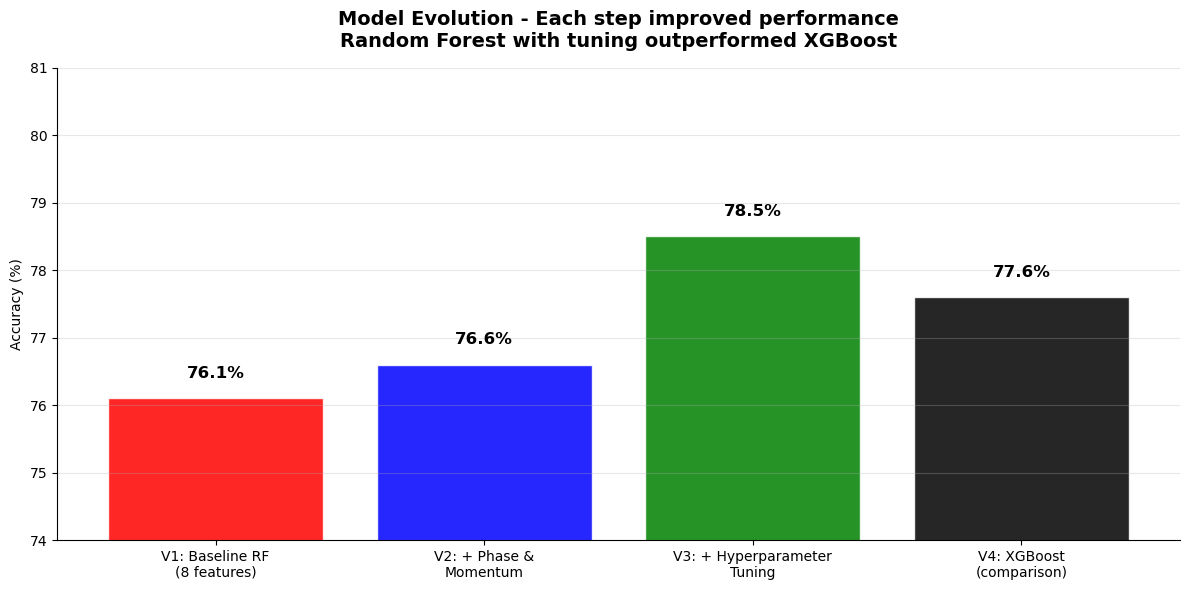

In [35]:
fig, ax = plt.subplots(figsize = (12, 6))

models = ['V1: Baseline RF\n(8 features)', 'V2: + Phase &\nMomentum',
         'V3: + Hyperparameter\nTuning', 'V4: XGBoost\n(comparison)']

accuracies = [76.1, 76.6, 78.5, 77.6]
colors = ['red', 'blue', 'green', 'black']

bars = ax.bar(models, accuracies, color = colors, alpha = 0.85, edgecolor = 'white')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc}%', ha = 'center', fontsize = 12, fontweight = 'bold')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Evolution - Each step improved performance\nRandom Forest with tuning outperformed XGBoost', 
            fontsize=14, fontweight = 'bold', pad = 15)
ax.set_ylim(74, 81)

ax.axhline(y = 50, color = 'gray', linestyle = ':', alpha = 0.3, label = 'Random guess (50%)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.savefig('phase2_08_model_comparison.png', dpi = 150)
plt.show()

## Key Findings

1. **Pressure (rr_gap) is the number 1 predictor -** The gap between required and current run rate drives predictions more than any other feature (44% importance).

2. **Individual balls don't matter -** Boundaries and dots have near-zero feature importance. Matches are decided by cumulative match state, not single shots.

3. **Aggression helps in death overs when behind -** Boundaries boost win probability by 3.5% when far behind in death overs.

4. **Aggression hurts in the powerplay -** Boundaries reduce win probability by up to 10.9% in the powerplay. Teams should preserve wickets early and attack late.

5. **The model is honest about uncertainty -** 99.3% accurate in extreme situations, 69% in close powerplay matches. Close matches are genuinely hard to predict.

## Phase 1 -> Phase 2 Connection

Phase 1 showed powerplay aggression increased the most over 18 seasons. Phase 2 reveals that may actually be the wrong strategy, the data suggests teams should defend in the powerplay and save aggression for the death overs.

## Two types of mistakes model can make:
1. **Mistake 1:** Model says "attack" but team should have defended. This is dangerous, the batsman swings hard, gets caught, loses a wicket. The team might lose the match because of this bad recommendation.

2. **Mistake 2:** Model says "defend" but team should have attacked. This is less harmful, the batsman plays safe, scores fewer runs, but keeps their wicket. They can still attack later.

In other words predicting **"attack"** when defending would have been better could cost a wicket. Predicting **"defend"** when attacking was needed only costs a few runs. The cost of errors is asymmetric - false positives (wrongly predicting a win) are more dangerous than false negatives.

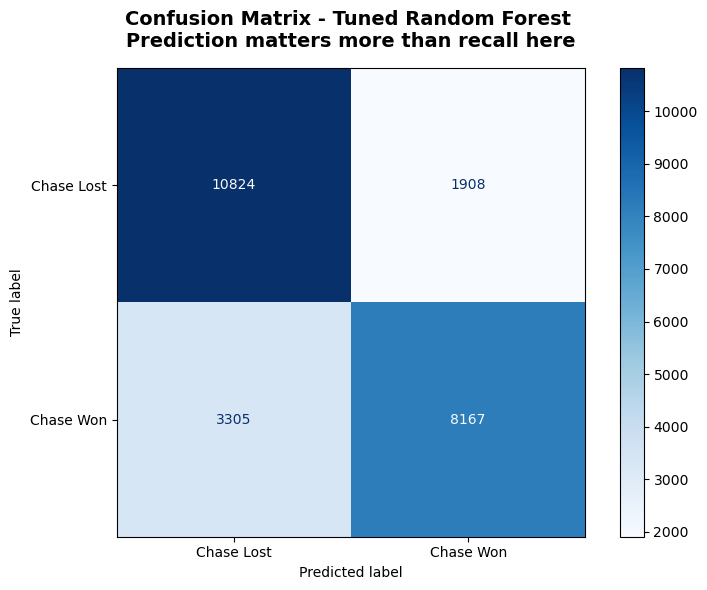

False Positives (predicted win, actually lost): 1908
False Negatives (predicted loss, actually won: 3305

Precision (class 1): 0.811
Recall (class 1): 0.712


In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig,ax = plt.subplots(figsize = (8, 6))
cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(cm , display_labels = ['Chase Lost', 'Chase Won'])
disp.plot(ax = ax, cmap = 'Blues', values_format = 'd')
ax.set_title('Confusion Matrix - Tuned Random Forest \nPrediction matters more than recall here', 
            fontsize = 14, fontweight = 'bold', pad = 15)
plt.tight_layout()
plt.savefig('phase2_09_confusion_matrix.png', dpi = 150)

plt.show()

print(f"False Positives (predicted win, actually lost): {cm[0][1]}")
print(f"False Negatives (predicted loss, actually won: {cm[1][0]}")
print(f"\nPrecision (class 1): {cm[1][1]/(cm[0][1] + cm[1][1]):.3f}")
print(f"Recall (class 1): {cm[1][1]/(cm[1][0] + cm[1][1]):.3f}")


**Precision: 0.811 -** When the model says "this situation favours the chasing team" (attack), its 81.1% of the time. That's good because false attacks are costly.

**Recall: 0.712 -** When the model catches 71 % of actual winning situations. It misses some opportunities to attack, but that's the safer mistake.

**False Positives: 1,908 -** times the model wrongly said "attack" (dangerous mistake)
**False Negatives: 3,305 -** time the model wrongly said "defend" (safe mistake)

The model makes more of the safer mistakes (3,305) than the dangerous one (1,908). That's actually the right behaviour for a strategy recommendation system, better to be cautiously wrong than aggressively wrong.

## Threshold Analysis - Tuning the Model's Aggressiveness

The deafult threshold is 0.50: if the model predicts > 50% win probability, it recommends "attack". But since the false positives (recommending attack when defending was better) are more costly than false negatives, we can raise the threshold to make the model more conservative. This is analogous to adjusting the significance level in hypothesis testing, a stricter threshold (like p < 0.01 vs p < 0.05) means fewer false discoveries but more missed signals.

In [37]:
# THRESHOLD ANALYSIS: How conservation should the model be?

# Higher threshold = more conservative = fewer false attacks
# Lower threshold = more aggressive = catches more wins but more false alarms

y_prob_best = best_model.predict_proba(X_test)[:, 1]
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

print("Threshold | Precision | Recall | F1 score | False Postivies | False Negatives")
print("-" * 90)

results = []
for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)

    # Predicision: when we say "attack", how often are we right?
    prec = cm_t[1][1]/ (cm_t[0][1] + cm_t[1][1]) if (cm_t[0][1] + cm_t[1][1]) > 0 else 0

    # Recall: of all actual winning situations, how many did we catch?
    rec = cm_t[1][1] / (cm_t[1][0] + cm_t[1][1]) if (cm_t[1][0] + cm_t[1][1]) > 0 else 0
    # F1: harmonic mean of precision and recall
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    fp = cm_t[0][1]
    fn = cm_t[1][0]
    marker = "DEAFULT" if thresh == 0.50 else ""
    print(f" {thresh:.2f} | {prec:.3f} | {rec:.3f} | {f1:.3f} | {fp:>5} | {fn:>5} {marker}")
    results.append({'threshold': thresh, 'precision': prec, 'recall': rec, 'f1': f1, 'fp': fp, 'fn': fn})

Threshold | Precision | Recall | F1 score | False Postivies | False Negatives
------------------------------------------------------------------------------------------
 0.40 | 0.762 | 0.807 | 0.784 |  2898 |  2209 
 0.45 | 0.783 | 0.764 | 0.774 |  2427 |  2702 
 0.50 | 0.811 | 0.712 | 0.758 |  1908 |  3305 DEAFULT
 0.55 | 0.830 | 0.656 | 0.733 |  1539 |  3945 
 0.60 | 0.844 | 0.592 | 0.696 |  1255 |  4679 
 0.65 | 0.859 | 0.536 | 0.660 |  1011 |  5328 
 0.70 | 0.876 | 0.467 | 0.609 |   761 |  6116 


The table shows how the precision-recall tradeoff works in practice:

**At the default threshold (0.5):**

- Precision = 0.811 - when the model says 'attack', it's correct 81.1% of the time
- Recall = 0.712 - it catches 71.2% of actual winning
- The model makes 1,908 dangerous mistakes (false attacks) vs 3,305 safe mistakes (which is missed oppotunities)
- That is a ratio of 1:1.75 - the model naturally makes nearly twice as many safe mistakes as dangerous ones.

**If we raise the threshold to 0.55:**
- Precision rises to 0.830, avoiding 369 dangerous false-attack recommendations
- But recall drops to 0.656, meaning we miss 640 more real winning situations.
- For high-stakes matches, this more conservative threshold might be preferred. 

**The model's natural asymmetry is correct for our use case:**
Precicting 'attack' when the team should defend costs a wicket (irreversible), while predicting "defend" when they should attack only costs a few runs (recoverable).
The default threshold already embodies this asymmetry, it does not need adjustment for general use, but a coach in a playoff match might prefer the 0.55 threshold for extra safety.

Therefore, the precision matters more than recall, and our model delivers strong precision (81.1%) while maintaining reasonable recall (71.2%).

In [40]:
import joblib
joblib.dump(best_model, 'ipl_chase_model.pkl')
print("Model saved!")


Model saved!
